In [35]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

df = pd.read_csv('videogames.csv')

#drop the "developer, publisher, and title"features from the dataframe "df"
df = df.drop(['developer','title'], axis=1)



In [36]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0] 
print("Columns with missing values:\n", missing_data)
df_cleaned = df.dropna()
print ("Remaining missing values:", df_cleaned.isnull().sum().sum())

Columns with missing values:
 critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
dtype: int64
Remaining missing values: 0


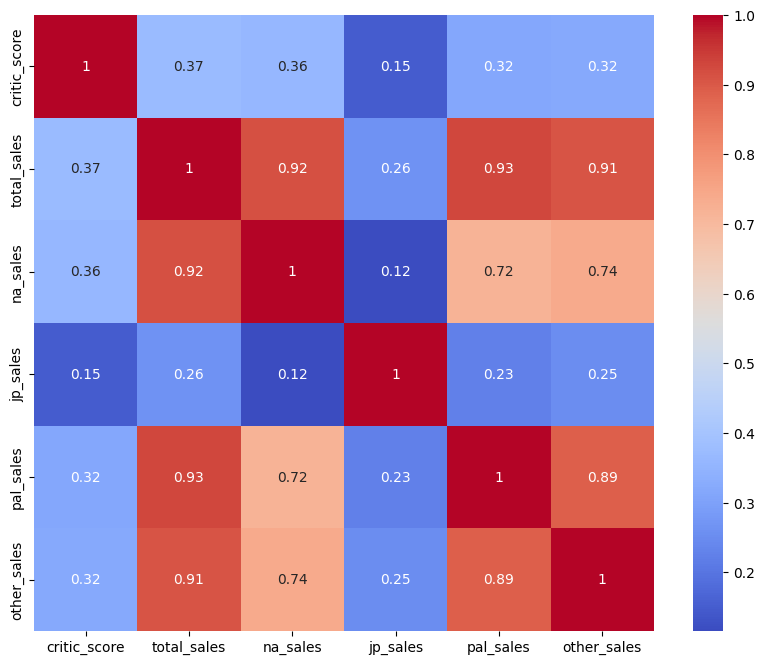

In [23]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.show()



Text(0, 0.5, 'Total Sales (In Millions)')

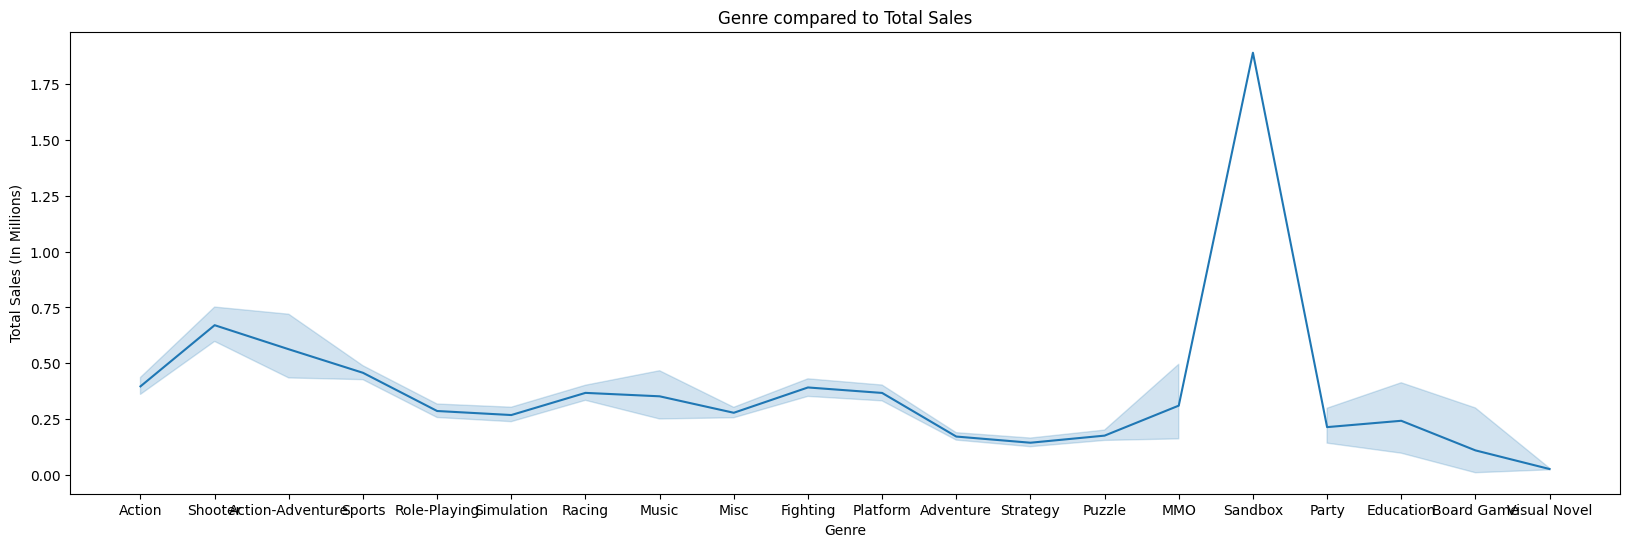

In [24]:
#Lineplot
plt.figure(figsize = (20,6))
sns.lineplot(x = 'genre', y = 'total_sales', data = df)
plt.title("Genre compared to Total Sales")
plt.xlabel("Genre")
plt.ylabel("Total Sales (In Millions)")

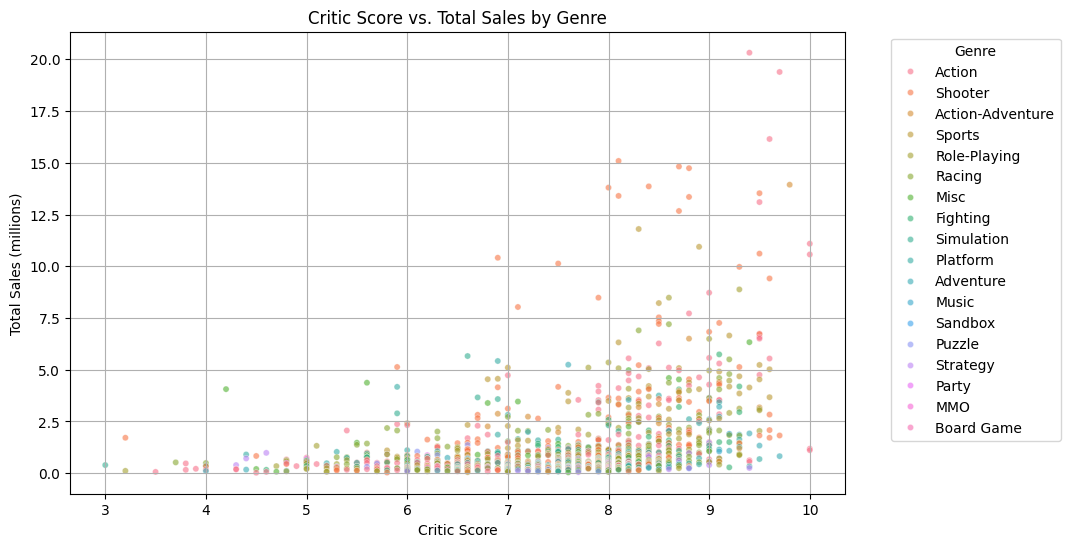

In [18]:
#Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_cleaned,
    x='critic_score',
    y='total_sales',
    hue='genre',
    s=20,
    alpha=0.6
)
plt.title('Critic Score vs. Total Sales by Genre')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (millions)')
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


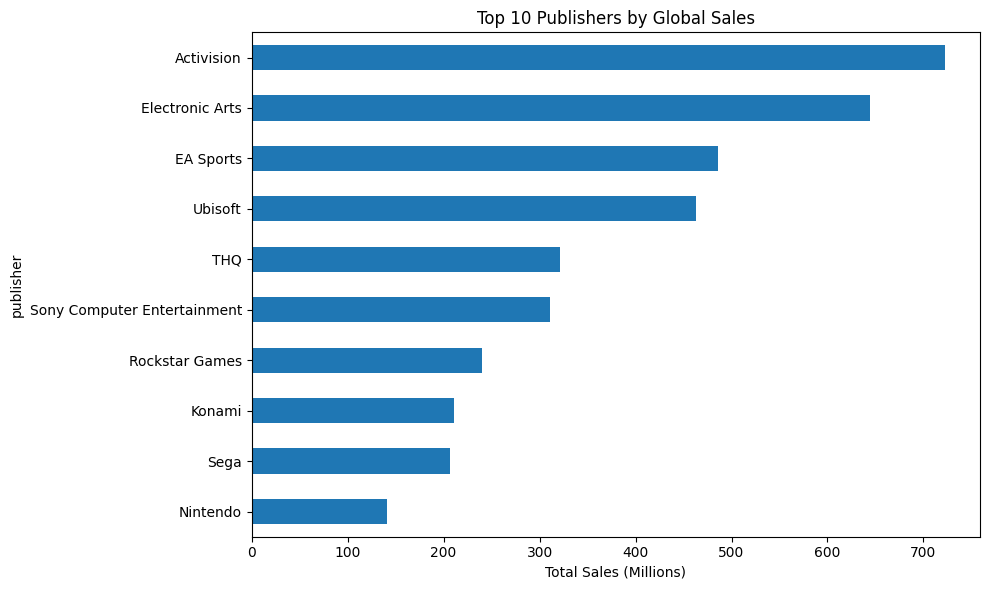

In [25]:
#Horizontal Bar Chart
top_publishers = df.groupby('publisher')['total_sales'].sum().sort_values(ascending=False).head(10)
top_publishers.plot(kind='barh', title='Top 10 Publishers by Global Sales', figsize=(10, 6))
plt.xlabel('Total Sales (Millions)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
plt. figure(figsize=(12, 6))
sns.barplot(data=df_cleaned, x="console", y="total_sales", palette="viridis")
plt.title("Total Sales by Console")
plt.xlabel ("Console")
plt.ylabel("Total Sales (millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt. show()

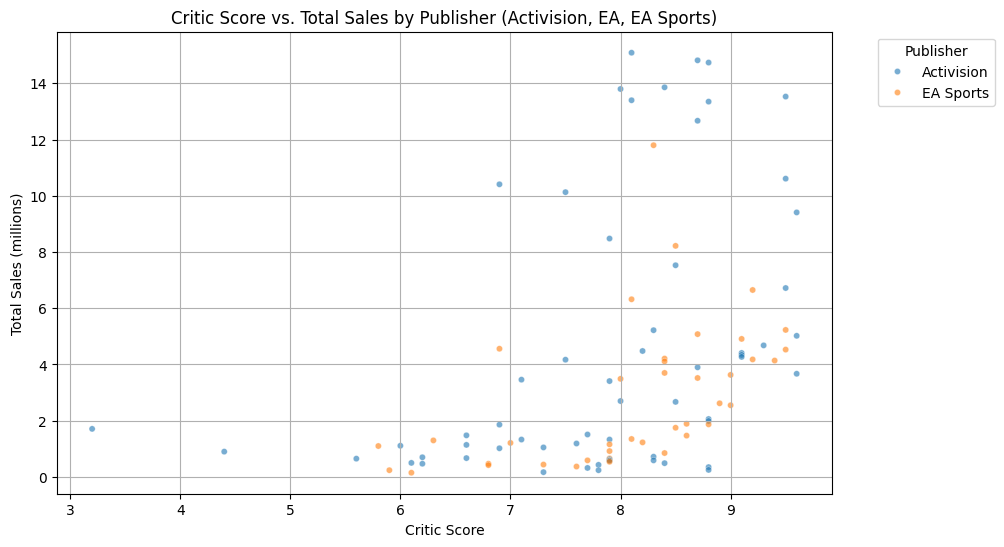

In [38]:
#Scatterplot
target_publishers = ['Activision', 'EA', 'EA Sports']
subset = df_cleaned[df_cleaned['publisher'].isin(target_publishers)]
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=subset,
    x='critic_score',
    y='total_sales',
    hue='publisher',
    s=20,
    alpha=0.6
)
plt.title('Critic Score vs. Total Sales by Publisher (Activision, EA, EA Sports)')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (millions)')
plt.legend(title="Publisher", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()
